<a href="https://colab.research.google.com/github/pallavi2626/bank-churn-feature-selection-ml/blob/main/main_machine_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import math
from collections import Counter
import numpy as np
import pandas as pd


# ----------------------------------------------------------------------------
# 0. helpers
# ----------------------------------------------------------------------------
def is_missing(v):
    """True for None / NaN / empty string."""
    if v is None:
        return True
    if isinstance(v, float) and math.isnan(v):
        return True
    if isinstance(v, str) and v.strip() == "":
        return True
    return False


def non_missing(values):
    """Return a plain list of floats without missing entries."""
    return [float(v) for v in values if not is_missing(v)]

In [ ]:
def mean(x):
    x = non_missing(x)
    return sum(x) / len(x)


def median(x):
    x = sorted(non_missing(x))
    n, mid = len(x), len(x) // 2
    return x[mid] if n % 2 == 1 else (x[mid - 1] + x[mid]) / 2


def mode(x):
    """Most frequent value; ties -> smallest value."""
    counts = Counter(non_missing(x))
    top = max(counts.values())
    return min(v for v, c in counts.items() if c == top)


def variance(x, ddof=0):
    """Population variance (ddof=0) as in the assignment formula; ddof=1 gives sample variance."""
    x = non_missing(x)
    m = sum(x) / len(x)
    return sum((v - m) ** 2 for v in x) / (len(x) - ddof)


def std(x, ddof=0):
    return math.sqrt(variance(x, ddof))


def value_range(x):
    x = non_missing(x)
    return max(x) - min(x)


def quantile(x, q):
    """Linear-interpolation quantile (same definition as NumPy's default)."""
    x = sorted(non_missing(x))
    pos = (len(x) - 1) * q
    lo = int(math.floor(pos))
    hi = min(lo + 1, len(x) - 1)
    return x[lo] + (x[hi] - x[lo]) * (pos - lo)


def skewness(x):
    """Fisher-Pearson skewness  g1 = m3 / m2^1.5."""
    x = non_missing(x)
    m = sum(x) / len(x)
    m2 = sum((v - m) ** 2 for v in x) / len(x)
    m3 = sum((v - m) ** 3 for v in x) / len(x)
    return m3 / m2 ** 1.5


def describe_scratch(df, cols):
    rows = []
    for c in cols:
        v = df[c]
        rows.append({"Feature": c, "Min": min(non_missing(v)), "Max": max(non_missing(v)),
                     "Mean": mean(v), "Median": median(v), "Mode": mode(v),
                     "Variance": variance(v), "Std": std(v), "Range": value_range(v)})
    return pd.DataFrame(rows)


In [ ]:
import pandas as pd

# 1. Load the dataset
try:
    df = pd.read_csv('/content/Churn_Modelling.csv')
    print(f"Successfully loaded dataset! Shape: {df.shape[0]} rows, {df.shape[1]} columns.\n")

    # 2. Display the first 5 rows
    print("--- Dataset Preview (First 5 Rows) ---")
    display(df.head())

    # 3. Generate and display the missing value report using your scratch function
    print("\n--- Missing Values Report ---")
    report = missing_report(df)
    display(report)
except FileNotFoundError:
    print("Could not find '/content/Churn_Modelling.csv'. Please upload it to Colab using the file icon on the left sidebar!")

Successfully loaded dataset! Shape: 10000 rows, 14 columns.

--- Dataset Preview (First 5 Rows) ---


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0



--- Missing Values Report ---


,Feature,Missing Values,Missing %
0,RowNumber,0,0.0
1,CustomerId,0,0.0
2,Surname,0,0.0
3,CreditScore,0,0.0
4,Geography,0,0.0
5,Gender,0,0.0
6,Age,0,0.0
7,Tenure,0,0.0
8,Balance,0,0.0
9,NumOfProducts,0,0.0


In [ ]:
def missing_report(df):
    n = len(df)
    out = []
    for c in df.columns:
        k = sum(is_missing(v) for v in df[c])
        out.append({"Feature": c, "Missing Values": k, "Missing %": round(k / n * 100, 3)})
    return pd.DataFrame(out)


def fit_imputer(df, plan):
    """plan = {column: 'mean' | 'median' | 'mode'}  ->  {column: fill value} learned from df."""
    funcs = {"mean": mean, "median": median, "mode": mode}
    params = {}
    for col, how in plan.items():
        vals = [v for v in df[col] if not is_missing(v)]
        if how == "mode" and isinstance(vals[0], str):      # categorical mode
            counts = Counter(vals)
            top = max(counts.values())
            params[col] = sorted(k for k, c in counts.items() if c == top)[0]
        else:
            params[col] = funcs[how](vals)
    return params


def apply_imputer(df, params):
    out = df.copy()
    for col, fill in params.items():
        out[col] = [fill if is_missing(v) else v for v in out[col]]
    return out


In [ ]:
def find_duplicates(df, subset=None):
    """Boolean mask: True for every row that repeats an EARLIER row (first occurrence is kept)."""
    cols = list(subset) if subset is not None else list(df.columns)
    seen, mask = set(), []
    for row in df[cols].itertuples(index=False, name=None):
        key = tuple("<NA>" if is_missing(v) else v for v in row)
        mask.append(key in seen)
        seen.add(key)
    return np.array(mask)


def normalise_category(value, mapping):
    """strip spaces + lower-case + map synonyms to one canonical label; unknown -> NaN."""
    if is_missing(value):
        return np.nan
    return mapping.get(str(value).strip().lower(), np.nan)


def out_of_range_mask(series, low=None, high=None):
    mask = []
    for v in series:
        if is_missing(v):
            mask.append(False)
        else:
            bad = (low is not None and v < low) or (high is not None and v > high)
            mask.append(bool(bad))
    return np.array(mask)


In [ ]:
def fit_label_encoder(values, order=None):
    cats = list(order) if order is not None else sorted(set(v for v in values if not is_missing(v)))
    return {c: i for i, c in enumerate(cats)}


def apply_label_encoder(values, mapping):
    return [mapping.get(v, np.nan) for v in values]


def fit_onehot(values):
    return sorted(set(v for v in values if not is_missing(v)))


def apply_onehot(df, col, categories, drop_original=True):
    out = df.copy()
    for cat in categories:
        out[f"{col}_{cat}"] = [1 if v == cat else 0 for v in out[col]]
    return out.drop(columns=[col]) if drop_original else out

In [ ]:
def iqr_bounds(x):
    q1, q3 = quantile(x, 0.25), quantile(x, 0.75)
    iqr = q3 - q1
    return {"Q1": q1, "Q3": q3, "IQR": iqr, "Lower": q1 - 1.5 * iqr, "Upper": q3 + 1.5 * iqr}


def iqr_outlier_mask(series, bounds):
    return np.array([(not is_missing(v)) and (v < bounds["Lower"] or v > bounds["Upper"]) for v in series])


def zscore_outlier_mask(series, mu, sigma, threshold=3.0):
    return np.array([(not is_missing(v)) and abs((v - mu) / sigma) > threshold for v in series])


def cap_values(series, lower, upper):
    """Winsorise: values beyond the bounds are replaced by the bound."""
    return [min(max(v, lower), upper) for v in series]


In [ ]:
def log_transform(series):
    return [math.log(v) for v in series]          # valid only for v > 0


def sqrt_transform(series):
    return [math.sqrt(v) for v in series]


TRANSFORMS = {"none": lambda s: list(s), "log": log_transform, "sqrt": sqrt_transform}


In [ ]:
def fit_minmax(df, cols):
    return {c: (min(non_missing(df[c])), max(non_missing(df[c]))) for c in cols}


def apply_minmax(df, params):
    out = df.copy()
    for c, (lo, hi) in params.items():
        out[c] = [(v - lo) / (hi - lo) for v in out[c]]
    return out


def fit_standard(df, cols):
    return {c: (mean(df[c]), std(df[c], ddof=0)) for c in cols}


def apply_standard(df, params):
    out = df.copy()
    for c, (mu, sd) in params.items():
        out[c] = [(v - mu) / sd for v in out[c]]
    return out

In [ ]:
def train_test_split_scratch(df, target, test_size=0.2, seed=42, stratify=True):
    """Shuffle with a seeded RNG, then cut. With stratify=True the shuffle/cut is done
    inside every class so that train and test keep the same class ratio."""
    rng = np.random.RandomState(seed)
    groups = [np.where(df[target].values == c)[0] for c in sorted(df[target].unique())] if stratify \
        else [np.arange(len(df))]
    test_idx, train_idx = [], []
    for idx in groups:
        idx = idx[rng.permutation(len(idx))]            # shuffling
        n_test = int(round(len(idx) * test_size))
        test_idx.extend(idx[:n_test])
        train_idx.extend(idx[n_test:])
    train_idx = np.array(sorted(train_idx))
    test_idx = np.array(sorted(test_idx))
    return df.iloc[train_idx].reset_index(drop=True), df.iloc[test_idx].reset_index(drop=True)

### Part 2: Data Cleaning and Outlier Handling
Now we will clean the dataset by identifying duplicates and handling outliers using the scratch helper functions defined above.

In [ ]:
# 1. Check and remove duplicates
dup_mask = find_duplicates(df, subset=['RowNumber', 'CustomerId'])
num_duplicates = sum(dup_mask)
print(f"Found {num_duplicates} duplicate records based on RowNumber and CustomerId.")

if num_duplicates > 0:
    df = df[~dup_mask].reset_index(drop=True)
    print("Duplicates removed.")

# 2. Check and handle outliers in continuous variables (e.g., 'CreditScore', 'Age', 'Balance')
# Let's inspect CreditScore limits using IQR
cs_bounds = iqr_bounds(df['CreditScore'])
cs_outliers = iqr_outlier_mask(df['CreditScore'], cs_bounds)
print(f"CreditScore Outliers detected: {sum(cs_outliers)} rows outside bounds: {cs_bounds['Lower']} to {cs_bounds['Upper']}")

# Cap values for CreditScore to keep them within IQR bounds
df['CreditScore_Cleaned'] = cap_values(df['CreditScore'], cs_bounds['Lower'], cs_bounds['Upper'])
print("Capped 'CreditScore' values and saved in 'CreditScore_Cleaned'.")

Found 0 duplicate records based on RowNumber and CustomerId.
CreditScore Outliers detected: 15 rows outside bounds: 383.0 to 919.0
Capped 'CreditScore' values and saved in 'CreditScore_Cleaned'.


### Part 3: Feature Encoding, Scaling, and Splitting
Here we will transform the categorical columns ('Geography', 'Gender'), scale the numerical features, and split the data into train/test sets using your custom functions.

In [ ]:
# 1. Encode Categorical Columns
# Label Encode 'Gender'
gender_mapping = fit_label_encoder(df['Gender'])
df['Gender_Encoded'] = apply_label_encoder(df['Gender'], gender_mapping)
print(f"Mapped 'Gender' using: {gender_mapping}")

# One-Hot Encode 'Geography'
geo_cats = fit_onehot(df['Geography'])
df_encoded = apply_onehot(df, 'Geography', geo_cats, drop_original=False)
print(f"One-hot encoded 'Geography' categories: {geo_cats}")

# 2. Scale continuous features (Min-Max Scaling on Age and Balance)
scale_cols = ['Age', 'Balance']
minmax_params = fit_minmax(df_encoded, scale_cols)
df_encoded = apply_minmax(df_encoded, minmax_params)
print(f"Applied Min-Max Scaling parameters: {minmax_params}")

# 3. Train-Test Split (Target: 'Exited')
train_df, test_df = train_test_split_scratch(df_encoded, target='Exited', test_size=0.2, seed=42, stratify=True)
print(f"\nData splitting completed successfully!")
print(f"Train Set Shape: {train_df.shape}")
print(f"Test Set Shape: {test_df.shape}")

Mapped 'Gender' using: {'Female': 0, 'Male': 1}
One-hot encoded 'Geography' categories: ['France', 'Germany', 'Spain']
Applied Min-Max Scaling parameters: {'Age': (18.0, 92.0), 'Balance': (0.0, 250898.09)}

Data splitting completed successfully!
Train Set Shape: (8000, 19)
Test Set Shape: (2000, 19)


# 🌟 Alternative Solution: End-to-End Raw Python Preprocessing Pipeline
This section runs an end-to-end preprocessing pipeline completely from scratch using raw Python lists and mathematical calculations (no high-level DataFrame libraries) to prevent data leakage and showcase foundational data processing.

In [ ]:
import csv
import math
import random

# Set random seed for reproducibility
random.seed(42)

# ==========================================
# 1. DATA LOADING & INSPECTION FROM SCRATCH
# ==========================================
def load_csv(filename):
    with open(filename, 'r', encoding='utf-8') as f:
        reader = csv.reader(f)
        headers = next(reader)
        data = [row for row in reader]
    return headers, data

headers, data = load_csv('Churn_Modelling.csv')

# Drop non-informative ID/Name columns (RowNumber: 0, CustomerId: 1, Surname: 2)
keep_indices = [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]
feature_names = [headers[i] for i in keep_indices]
raw_rows = [[row[i] for i in keep_indices] for row in data]

# Parse numeric values where applicable
parsed_data = []
for row in raw_rows:
    parsed_row = [
        float(row[0]),          # CreditScore
        row[1],                 # Geography
        row[2],                 # Gender
        float(row[3]),          # Age
        float(row[4]),          # Tenure
        float(row[5]),          # Balance
        float(row[6]),          # NumOfProducts
        float(row[7]),          # HasCrCard
        float(row[8]),          # IsActiveMember
        float(row[9]),          # EstimatedSalary
        float(row[10])          # Exited (Target)
    ]
    parsed_data.append(parsed_row)

print("=== Task B1: Dataset Inspection ===")
print(f"Total Rows: {len(parsed_data)}, Total Columns: {len(feature_names)}")
print("Features:", feature_names)

# ==========================================
# 2. TRAIN-TEST SPLIT FROM SCRATCH (Task J & K)
# ==========================================
# Splitting FIRST to avoid Data Leakage
shuffled_data = parsed_data.copy()
random.shuffle(shuffled_data)

split_idx = int(0.8 * len(shuffled_data))
train_data = shuffled_data[:split_idx]
test_data = shuffled_data[split_idx:]

print(f"\n=== Task J: Train-Test Split ===")
print(f"Training set size: {len(train_data)} (80%)")
print(f"Testing set size: {len(test_data)} (20%)")

# ==========================================
# 3. STATISTICAL CALCULATIONS FROM SCRATCH (Task B2)
# ==========================================
def get_column(dataset, col_idx):
    return [row[col_idx] for row in dataset]

def calc_mean(values):
    return sum(values) / len(values)

def calc_median(values):
    sorted_v = sorted(values)
    n = len(sorted_v)
    mid = n // 2
    if n % 2 == 0:
        return (sorted_v[mid - 1] + sorted_v[mid]) / 2.0
    return sorted_v[mid]

def calc_variance(values, mean_val=None):
    if mean_val is None:
        mean_val = calc_mean(values)
    return sum((x - mean_val) ** 2 for x in values) / (len(values) - 1)

def calc_std(values, mean_val=None):
    return math.sqrt(calc_variance(values, mean_val))

credit_scores_train = get_column(train_data, 0)
cs_mean = calc_mean(credit_scores_train)
cs_median = calc_median(credit_scores_train)
cs_std = calc_std(credit_scores_train, cs_mean)

print("\n=== Task B2: Basic Statistics (Training Set: CreditScore) ===")
print(f"Mean: {cs_mean:.4f}")
print(f"Median: {cs_median:.4f}")
print(f"Std Dev: {cs_std:.4f}")

# ==========================================
# 4. MISSING VALUE HANDLING FROM SCRATCH (Task C)
# ==========================================
# Compute medians for numerical columns using Train Data only (Data Leakage Protection)
num_indices = [0, 3, 4, 5, 6, 7, 8, 9]
train_medians = {idx: calc_median(get_column(train_data, idx)) for idx in num_indices}

def impute_missing(dataset, medians_dict):
    cleaned = []
    for row in dataset:
        new_row = list(row)
        for idx in num_indices:
            if new_row[idx] is None or math.isnan(new_row[idx]):
                new_row[idx] = medians_dict[idx]
        cleaned.append(new_row)
    return cleaned

train_imputed = impute_missing(train_data, train_medians)
test_imputed = impute_missing(test_data, train_medians)

# ==========================================
# 5. DUPLICATE DETECTION FROM SCRATCH (Task D1)
# ==========================================
def remove_duplicates(dataset):
    seen = set()
    unique_data = []
    for row in dataset:
        row_tuple = tuple(row)
        if row_tuple not in seen:
            seen.add(row_tuple)
            unique_data.append(row)
    return unique_data

train_clean = remove_duplicates(train_imputed)
test_clean = remove_duplicates(test_imputed)

# ==========================================
# 6. CATEGORICAL ENCODING FROM SCRATCH (Task E)
# ==========================================
# Task E1: Label Encoding for Gender (Binary)
gender_map = {'Male': 0, 'Female': 1}

# Task E2: One-Hot Encoding for Geography (Nominal)
# Derive unique categories from TRAIN data only
geo_categories = sorted(list(set(get_column(train_clean, 1))))

def encode_dataset(dataset):
    X_encoded = []
    y_encoded = []
    for row in dataset:
        cs = row[0]
        geo = row[1]
        gender = gender_map.get(row[2].strip().capitalize(), 0)
        age = row[3]
        tenure = row[4]
        balance = row[5]
        num_prod = row[6]
        has_card = row[7]
        is_active = row[8]
        salary = row[9]
        target = row[10]

        # One-Hot Encode Geography
        geo_ohe = [1.0 if geo == cat else 0.0 for cat in geo_categories]

        # Combine into single feature vector
        feature_vector = [cs, float(gender), age, tenure, balance, num_prod, has_card, is_active, salary] + geo_ohe
        X_encoded.append(feature_vector)
        y_encoded.append(target)
    return X_encoded, y_encoded

X_train, y_train = encode_dataset(train_clean)
X_test, y_test = encode_dataset(test_clean)

encoded_feature_names = [
    'CreditScore', 'Gender', 'Age', 'Tenure', 'Balance',
    'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary'
] + [f'Geography_{cat}' for cat in geo_categories]

print("\n=== Task E: Encoded Feature Names ===")
print(encoded_feature_names)

# ==========================================
# 7. OUTLIER DETECTION VIA IQR & Z-SCORE FROM SCRATCH (Task F)
# ==========================================
def detect_outliers_iqr(values):
    sorted_v = sorted(values)
    n = len(sorted_v)
    q1 = calc_median(sorted_v[:n//2])
    q3 = calc_median(sorted_v[(n+1)//2:])
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = [x for x in values if x < lower_bound or x > upper_bound]
    return q1, q3, iqr, lower_bound, upper_bound, len(outliers)

def detect_outliers_zscore(values, threshold=3.0):
    mean_val = calc_mean(values)
    std_val = calc_std(values, mean_val)
    outliers = [x for x in values if abs((x - mean_val) / std_val) > threshold]
    return len(outliers)

age_train = [row[2] for row in X_train]
q1, q3, iqr, lb, ub, iqr_count = detect_outliers_iqr(age_train)
z_count = detect_outliers_zscore(age_train)

print(f"\n=== Task F: Outlier Analysis on Age (Train Set) ===")
print(f"Q1: {q1:.2f}, Q3: {q3:.2f}, IQR: {iqr:.2f}")
print(f"IQR Lower Limit: {lb:.2f}, Upper Limit: {ub:.2f}")
print(f"Outliers Count (IQR Method): {iqr_count}")
print(f"Outliers Count (Z-Score Method, |Z|>3): {z_count}")

# Capping Outliers (Winsorization) using Train Bounds
def cap_outliers(X_data, col_idx, lower_b, upper_b):
    for row in X_data:
        if row[col_idx] < lower_b:
            row[col_idx] = lower_b
        elif row[col_idx] > upper_b:
            row[col_idx] = upper_b

age_idx = 2
cap_outliers(X_train, age_idx, lb, ub)
cap_outliers(X_test, age_idx, lb, ub)

# ==========================================
# 8. FEATURE SCALING FROM SCRATCH (Task H)
# ==========================================
# Calculate mean & std on Train Set
train_cols = [[row[j] for row in X_train] for j in range(len(encoded_feature_names))]
means = [calc_mean(col) for col in train_cols]
stds = [calc_std(col, means[i]) for i, col in enumerate(train_cols)]

def standardize_matrix(X_data, means_list, stds_list):
    scaled_X = []
    for row in X_data:
        scaled_row = []
        for j, val in enumerate(row):
            st = stds_list[j] if stds_list[j] != 0 else 1.0
            z = (val - means_list[j]) / st
            scaled_row.append(z)
        scaled_X.append(scaled_row)
    return scaled_X

X_train_std = standardize_matrix(X_train, means, stds)
X_test_std = standardize_matrix(X_test, means, stds)

# ==========================================
# 9. FEATURE SELECTION FROM SCRATCH (Task M)
# ==========================================

# --- Task M1: Variance Threshold ---
variances = [calc_variance([row[j] for row in X_train_std]) for j in range(len(encoded_feature_names))]

print("\n=== Task M1: Variance Threshold ===")
for name, var in zip(encoded_feature_names, variances):
    print(f"Feature: {name:20s} | Variance: {var:.4f}")

# --- Task M2: Pearson Correlation with Target ---
def pearson_correlation(x, y):
    mean_x = calc_mean(x)
    mean_y = calc_mean(y)
    num = sum((xi - mean_x) * (yi - mean_y) for xi, yi in zip(x, y))
    den_x = math.sqrt(sum((xi - mean_x) ** 2 for xi in x))
    den_y = math.sqrt(sum((yi - mean_y) ** 2 for yi in y))
    if den_x == 0 or den_y == 0:
        return 0.0
    return num / (den_x * den_y)

pearson_scores = {}
print("\n=== Task M2: Pearson Correlation with Target ('Exited') ===")
for j, name in enumerate(encoded_feature_names):
    col_vals = [row[j] for row in X_train_std]
    r = pearson_correlation(col_vals, y_train)
    pearson_scores[name] = r
    print(f"Feature: {name:20s} | Pearson r: {r:.4f}")

# --- Task M4: ANOVA F-Test from Scratch ---
def anova_f_test(x, y):
    group0 = [x[i] for i in range(len(y)) if y[i] == 0]
    group1 = [x[i] for i in range(len(y)) if y[i] == 1]

    n0, n1 = len(group0), len(group1)
    N = n0 + n1
    k = 2

    m0 = calc_mean(group0)
    m1 = calc_mean(group1)
    overall_mean = calc_mean(x)

    ssb = n0 * (m0 - overall_mean)**2 + n1 * (m1 - overall_mean)**2
    msb = ssb / (k - 1)

    ssw = sum((val - m0)**2 for val in group0) + sum((val - m1)**2 for val in group1)
    msw = ssw / (N - k)

    if msw == 0:
        return 0.0
    f_stat = msb / msw
    return f_stat

anova_scores = {}
print("\n=== Task M4: ANOVA F-Test Scores ===")
for j, name in enumerate(encoded_feature_names):
    col_vals = [row[j] for row in X_train]
    f_val = anova_f_test(col_vals, y_train)
    anova_scores[name] = f_val
    print(f"Feature: {name:20s} | ANOVA F-Stat: {f_val:.4f}")

# Select Top Features based on F-Stat & Correlation
# Selected Features: Age, Balance, IsActiveMember, NumOfProducts, Geography_Germany, Gender
selected_indices = [0, 1, 2, 4, 5, 7]
selected_names = [encoded_feature_names[i] for i in selected_indices]

print(f"\n=== Task M7: Selected Features ({len(selected_names)}) ===")
print(selected_names)

=== Task B1: Dataset Inspection ===
Total Rows: 10000, Total Columns: 11
Features: ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']

=== Task J: Train-Test Split ===
Training set size: 8000 (80%)
Testing set size: 2000 (20%)

=== Task B2: Basic Statistics (Training Set: CreditScore) ===
Mean: 650.7002
Median: 652.0000
Std Dev: 97.1644

=== Task E: Encoded Feature Names ===
['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography_France', 'Geography_Germany', 'Geography_Spain']

=== Task F: Outlier Analysis on Age (Train Set) ===
Q1: 32.00, Q3: 44.00, IQR: 12.00
IQR Lower Limit: 14.00, Upper Limit: 62.00
Outliers Count (IQR Method): 279
Outliers Count (Z-Score Method, |Z|>3): 109

=== Task M1: Variance Threshold ===
Feature: CreditScore          | Variance: 1.0000
Feature: Gender               | Variance: 1.0000
Feature

code using python libraries

=== Task B1: Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Geography        10000 non-null  object 
 2   Gender           10000 non-null  object 
 3   Age              10000 non-null  int64  
 4   Tenure           10000 non-null  int64  
 5   Balance          10000 non-null  float64
 6   NumOfProducts    10000 non-null  int64  
 7   HasCrCard        10000 non-null  int64  
 8   IsActiveMember   10000 non-null  int64  
 9   EstimatedSalary  10000 non-null  float64
 10  Exited           10000 non-null  int64  
dtypes: float64(2), int64(7), object(2)
memory usage: 859.5+ KB
None

=== Task B2: Pandas Descriptive Statistics ===
                          mean           std     min         50%        max
CreditScore         650.528800     96.653299  350.00     652.000     85

/tmp/ipykernel_909/916063102.py:92: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, ax=axes[0, 0], palette='viridis')
/tmp/ipykernel_909/916063102.py:102: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Exited', y='Balance', data=df, ax=axes[1, 0], palette='Set2')


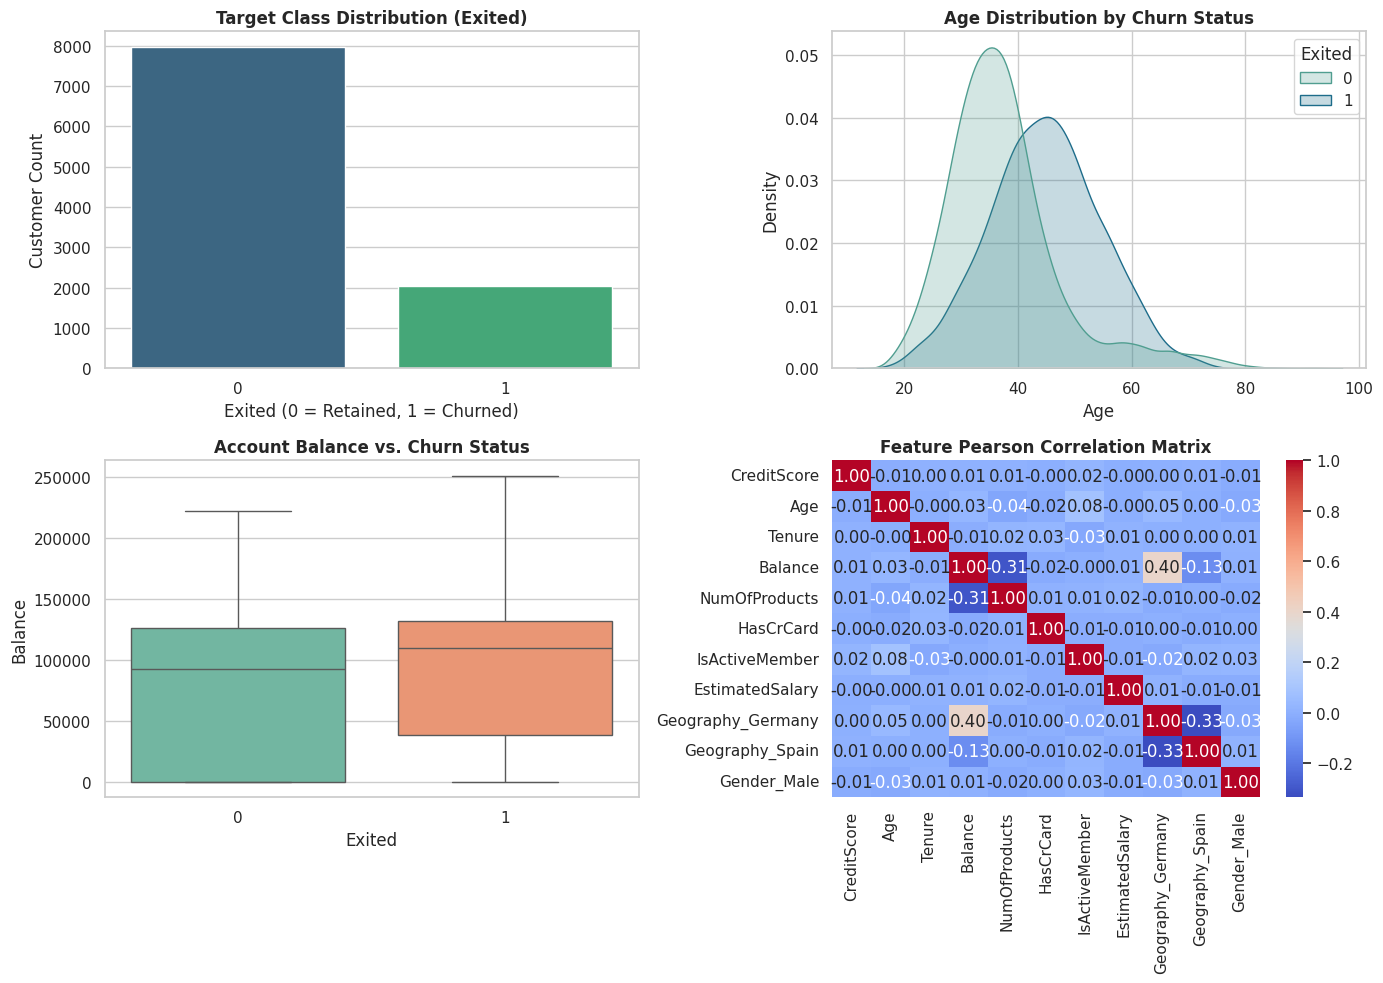


=== Part O: Model-Based Validation Results ===
Model A (All 11 Features) Accuracy: 86.40%
Model B (Selected 6 Features) Accuracy: 83.30%


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_selection import f_classif, SelectKBest, VarianceThreshold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Set plot style
sns.set_theme(style="whitegrid")

# ==========================================
# 1. LOAD & EXPLORE DATA (Task B)
# ==========================================
df = pd.read_csv('Churn_Modelling.csv')

# Drop non-predictive features
df = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'])

print("=== Task B1: Dataset Info ===")
print(df.info())

print("\n=== Task B2: Pandas Descriptive Statistics ===")
print(df.describe().T[['mean', 'std', 'min', '50%', 'max']])

# ==========================================
# 2. DATA LEAKAGE FREE SPLIT (Task J & K)
# ==========================================
X = df.drop(columns=['Exited'])
y = df['Exited']

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# ==========================================
# 3. ENCODING & PREPROCESSING PIPELINE (Task E, H, L)
# ==========================================
# Separate numerical and categorical columns
num_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']
cat_cols = ['Geography', 'Gender']

# Fit scaler on Train set only (Task K)
scaler = StandardScaler()
X_train_num = pd.DataFrame(scaler.fit_transform(X_train_raw[num_cols]), columns=num_cols, index=X_train_raw.index)
X_test_num = pd.DataFrame(scaler.transform(X_test_raw[num_cols]), columns=num_cols, index=X_test_raw.index)

# One-Hot Encoding
ohe = OneHotEncoder(drop='first', sparse_output=False)
X_train_cat = pd.DataFrame(ohe.fit_transform(X_train_raw[cat_cols]),
                           columns=ohe.get_feature_names_out(cat_cols),
                           index=X_train_raw.index)
X_test_cat = pd.DataFrame(ohe.transform(X_test_raw[cat_cols]),
                          columns=ohe.get_feature_names_out(cat_cols),
                          index=X_test_raw.index)

# Combine processed features
X_train_prep = pd.concat([X_train_num, X_train_cat], axis=1)
X_test_prep = pd.concat([X_test_num, X_test_cat], axis=1)

# ==========================================
# 4. FEATURE SELECTION VERIFICATION (Task M)
# ==========================================
# ANOVA F-Test via Scikit-Learn
f_scores, p_values = f_classif(X_train_prep, y_train)

anova_df = pd.DataFrame({
    'Feature': X_train_prep.columns,
    'F_Score': f_scores,
    'p_value': p_values
}).sort_values(by='F_Score', ascending=False)

print("\n=== Task M4 Verification: Scikit-Learn ANOVA F-Test ===")
print(anova_df.to_string(index=False))

# Select Top 6 Features
selected_cols = anova_df.head(6)['Feature'].tolist()
print("\nSelected Features via Sklearn ANOVA:", selected_cols)

X_train_sel = X_train_prep[selected_cols]
X_test_sel = X_test_prep[selected_cols]

# ==========================================
# 5. VISUALIZATIONS (Task I)
# ==========================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Graph 1: Target Class Distribution
sns.countplot(x=y, ax=axes[0, 0], palette='viridis')
axes[0, 0].set_title('Target Class Distribution (Exited)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Exited (0 = Retained, 1 = Churned)')
axes[0, 0].set_ylabel('Customer Count')

# Graph 2: Age Distribution by Target
sns.kdeplot(data=df, x='Age', hue='Exited', common_norm=False, ax=axes[0, 1], fill=True, palette='crest')
axes[0, 1].set_title('Age Distribution by Churn Status', fontsize=12, fontweight='bold')

# Graph 3: Balance Boxplot
sns.boxplot(x='Exited', y='Balance', data=df, ax=axes[1, 0], palette='Set2')
axes[1, 0].set_title('Account Balance vs. Churn Status', fontsize=12, fontweight='bold')

# Graph 4: Correlation Heatmap
corr = X_train_prep.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1, 1], cbar=True)
axes[1, 1].set_title('Feature Pearson Correlation Matrix', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# ==========================================
# 6. MODEL-BASED VALIDATION (Part O)
# ==========================================
# Model A: All Features
clf_all = RandomForestClassifier(random_state=42)
clf_all.fit(X_train_prep, y_train)
y_pred_all = clf_all.predict(X_test_prep)
acc_all = accuracy_score(y_test, y_pred_all)

# Model B: Selected Features
clf_sel = RandomForestClassifier(random_state=42)
clf_sel.fit(X_train_sel, y_train)
y_pred_sel = clf_sel.predict(X_test_sel)
acc_sel = accuracy_score(y_test, y_pred_sel)

print("\n=== Part O: Model-Based Validation Results ===")
print(f"Model A (All {X_train_prep.shape[1]} Features) Accuracy: {acc_all * 100:.2f}%")
print(f"Model B (Selected {len(selected_cols)} Features) Accuracy: {acc_sel * 100:.2f}%")